# Set 11 - NMF und t-SNE

Dieses Notebook zeigt zwei sehr unterschiedliche Arten der Dimensionsreduktion:

- NMF zerlegt nichtnegative Daten in additive Bausteine und Gewichte.
- t-SNE erzeugt eine zweidimensionale Visualisierung lokaler Nachbarschaften.

Beide Verfahren reduzieren Dimensionen, erhalten aber nicht dieselbe Struktur und dienen nicht demselben Zweck.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.stats import spearmanr
from sklearn.decomposition import NMF, PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use("seaborn-v0_8-whitegrid")


## 1. NMF: additive Muster in nichtnegativen Daten

Wir simulieren Spektren als Mischung aus drei positiven Grundmustern. NMF kennt diese Grundmuster nicht und versucht, sie allein aus der Datenmatrix zu rekonstruieren.


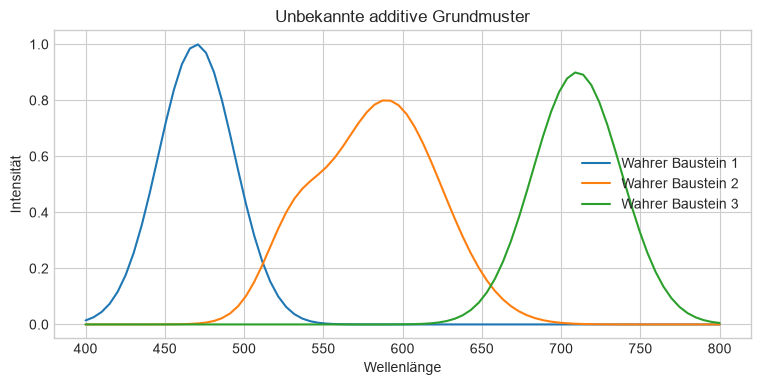

In [2]:
wavelengths = np.linspace(400, 800, 80)

def peak(center, width):
    return np.exp(-0.5*((wavelengths-center)/width)**2)

H_true = np.vstack([
    peak(470, 24),
    0.8*peak(590, 35) + 0.25*peak(530, 18),
    0.9*peak(710, 28),
])
W_true = rng.gamma(shape=1.8, scale=1.0, size=(240, 3))
X_spectra = W_true @ H_true + rng.normal(0, 0.025, size=(240, 80))
X_spectra = np.clip(X_spectra, 0, None)

plt.figure(figsize=(9, 4))
for i, component in enumerate(H_true, 1):
    plt.plot(wavelengths, component, label=f"Wahrer Baustein {i}")
plt.xlabel("Wellenlänge"); plt.ylabel("Intensität")
plt.title("Unbekannte additive Grundmuster"); plt.legend(); plt.show()


Original: (240, 80)
Gewichte W: (240, 3) Bausteine H: (3, 80)
Rekonstruktionsfehler: 3.424


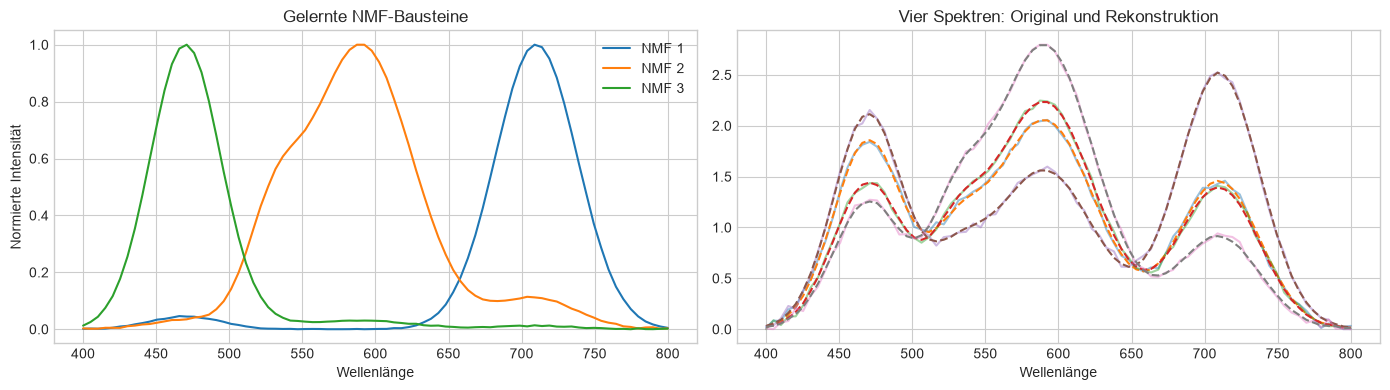

In [3]:
nmf = NMF(
    n_components=3, init="nndsvda",
    max_iter=2000, tol=1e-3, random_state=RANDOM_STATE
)
W_learned = nmf.fit_transform(X_spectra)
H_learned = nmf.components_

print("Original:", X_spectra.shape)
print("Gewichte W:", W_learned.shape, "Bausteine H:", H_learned.shape)
print("Rekonstruktionsfehler:", round(nmf.reconstruction_err_, 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, component in enumerate(H_learned, 1):
    axes[0].plot(wavelengths, component/component.max(), label=f"NMF {i}")
axes[0].set(title="Gelernte NMF-Bausteine", xlabel="Wellenlänge", ylabel="Normierte Intensität")
axes[0].legend()

sample_ids = [0, 1, 2, 3]
reconstruction = W_learned @ H_learned
for sample_id in sample_ids:
    axes[1].plot(wavelengths, X_spectra[sample_id], alpha=0.45)
    axes[1].plot(wavelengths, reconstruction[sample_id], linestyle="--")
axes[1].set(title="Vier Spektren: Original und Rekonstruktion", xlabel="Wellenlänge")
plt.tight_layout(); plt.show()


Die Reihenfolge und Skalierung der NMF-Komponenten ist nicht eindeutig. Inhaltlich zählt, ob sinnvolle positive Bausteine und gute Rekonstruktionen entstehen. NMF verlangt nichtnegative Eingaben und passt besonders zu Counts, Intensitäten oder Häufigkeiten.


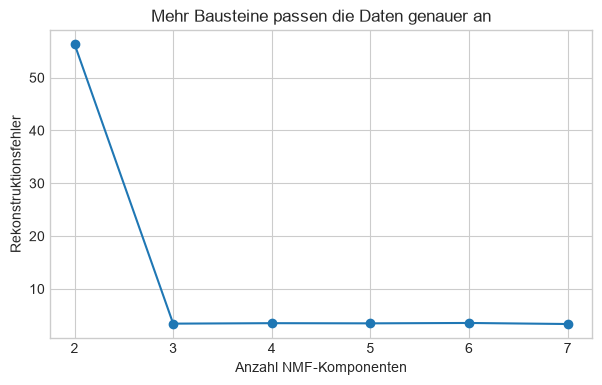

In [4]:
# Ab zwei Komponenten wird der interessante Knick bei drei Bausteinen sichtbar.
component_counts = range(2, 8)
errors = []
for n_components in component_counts:
    model = NMF(
        n_components=n_components, init="nndsvda",
        max_iter=2000, tol=1e-3, random_state=RANDOM_STATE
    ).fit(X_spectra)
    errors.append(model.reconstruction_err_)

plt.figure(figsize=(7, 4))
plt.plot(list(component_counts), errors, marker="o")
plt.xlabel("Anzahl NMF-Komponenten")
plt.ylabel("Rekonstruktionsfehler")
plt.title("Mehr Bausteine passen die Daten genauer an")
plt.show()


## 2. t-SNE: lokale Nachbarschaften sichtbar machen

Wir erzeugen eine gekrümmte, zweidimensionale Struktur und betten sie in einen Raum mit 15 Merkmalen ein. Die Farbe zeigt nur zur Kontrolle die verborgene Position entlang der Struktur; t-SNE erhält diese Information beim Fit nicht.


In [5]:
n_samples = 650
t = rng.uniform(1.5*np.pi, 4.5*np.pi, size=n_samples)
height = rng.uniform(-2.2, 2.2, size=n_samples)
base = np.c_[t*np.cos(t), height, t*np.sin(t)]
base += rng.normal(0, 0.16, size=base.shape)

nonlinear = np.c_[
    base,
    np.sin(base[:, [0, 2]]),
    np.cos(base[:, [0, 2]]),
    base[:, [0]]*base[:, [1]]/12,
    base[:, [1]]*base[:, [2]]/12,
    rng.normal(0, 0.35, size=(n_samples, 6)),
]
X_high = StandardScaler().fit_transform(nonlinear)
print("Hochdimensionale Darstellung:", X_high.shape)


Hochdimensionale Darstellung: (650, 15)


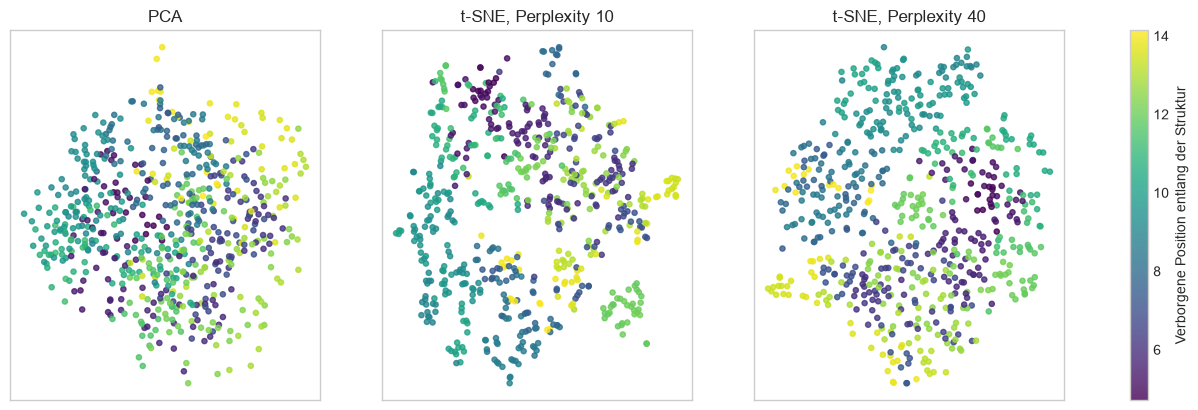

In [6]:
pca_embedding = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_high)
embeddings = {"PCA": pca_embedding}

for perplexity in [10, 40]:
    embeddings[f"t-SNE, Perplexity {perplexity}"] = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        max_iter=750,
        random_state=RANDOM_STATE,
    ).fit_transform(X_high)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, (name, embedding) in zip(axes, embeddings.items()):
    points = ax.scatter(
        embedding[:, 0], embedding[:, 1],
        c=t, cmap="viridis", s=14, alpha=0.8
    )
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(points, ax=axes, label="Verborgene Position entlang der Struktur")
plt.show()


## 3. Was bleibt erhalten?

Trustworthiness misst, wie gut lokale Nachbarschaften erhalten bleiben. Zusätzlich vergleichen wir auf einer Stichprobe die Rangkorrelation globaler Paarabstände. Ein t-SNE-Plot kann lokal sehr überzeugend sein, obwohl seine globale Geometrie nicht zuverlässig interpretierbar ist.


In [7]:
sample = rng.choice(n_samples, size=250, replace=False)
rows = []
original_distances = pdist(X_high[sample])

for name, embedding in embeddings.items():
    local_quality = trustworthiness(X_high, embedding, n_neighbors=12)
    global_correlation = spearmanr(
        original_distances, pdist(embedding[sample])
    ).statistic
    rows.append({
        "Darstellung": name,
        "Trustworthiness": local_quality,
        "Globale Distanz-Rangkorrelation": global_correlation,
    })

display(pd.DataFrame(rows).round(3))
print("Besitzt das trainierte t-SNE eine transform-Methode?",
      hasattr(TSNE(), "transform"))


,Darstellung,Trustworthiness,Globale Distanz-Rangkorrelation
0,PCA,0.707,0.356
1,"t-SNE, Perplexity 10",0.920,0.299
2,"t-SNE, Perplexity 40",0.929,0.390


Besitzt das trainierte t-SNE eine transform-Methode? False


## Fazit

- NMF erzeugt additive, nichtnegative Bausteine und kann neue Beobachtungen mit transform abbilden.
- PCA ist eine lineare Projektion und eignet sich häufig für Pipelines.
- t-SNE ist primär explorative Visualisierung; globale Abstände, Flächen und scheinbare Clustergrößen sind vorsichtig zu lesen.
- Perplexity, Initialisierung und Zufall können das Bild verändern.
- Ein schöner zweidimensionaler Plot ist kein Beweis für echte Cluster.
